In [1]:
# ============================================
# DATA CLEANING + EDA + KPI
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel("Refund_Failure_Analytics_Dataset.xlsx")

print("="*50)
print("DATASET SHAPE")
print(df.shape)

print("="*50)
print("FIRST 10 RECORDS")
print(df.head(10))

print("="*50)
print("DATASET INFO")
print(df.info())

print("="*50)
print("STATISTICS")
print(df.describe(include='all'))

print("="*50)
print("MISSING VALUES")
print(df.isnull().sum())

print("="*50)
print("DUPLICATE RECORDS")
print(df.duplicated().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

print("="*50)
print("DATA TYPES")
print(df.dtypes)

# ======================
# KPI
# ======================

total_receipts = len(df)
total_amount = df["Amount"].sum()
successful_payments = (df["Payment_Status"]=="Success").sum()
failed_payments = (df["Payment_Status"]=="Failed").sum()
total_refunds = (df["Refund_Status"]=="Refunded").sum()
refund_amount = df["Refund_Amount"].sum()

print("\n========== KPI ==========")
print("Total Receipts :", total_receipts)
print("Total Amount :", total_amount)
print("Successful Payments :", successful_payments)
print("Failed Payments :", failed_payments)
print("Refund Count :", total_refunds)
print("Refund Amount :", refund_amount)

DATASET SHAPE
(200, 9)
FIRST 10 RECORDS
  Receipt_ID        Date Student_ID          Course  Amount Payment_Status  \
0    RCP0001  2026-03-20    STU1001             SQL    1499         Failed   
1    RCP0002  2026-05-24    STU1002             SQL     999        Success   
2    RCP0003  2026-03-25    STU1003             SQL    2999        Success   
3    RCP0004  2026-05-08    STU1004          Python    1499         Failed   
4    RCP0005  2026-03-04    STU1005          Python    1499        Success   
5    RCP0006  2026-02-23    STU1006          Python     999        Success   
6    RCP0007  2026-01-03    STU1007           Excel    2499         Failed   
7    RCP0008  2026-02-07    STU1008           Excel    1999         Failed   
8    RCP0009  2026-01-22    STU1009  Data Analytics    2999        Success   
9    RCP0010  2026-06-08    STU1010  Data Analytics    2499         Failed   

  Refund_Status  Refund_Amount Payment_Method  
0     No Refund              0           Card  
1    

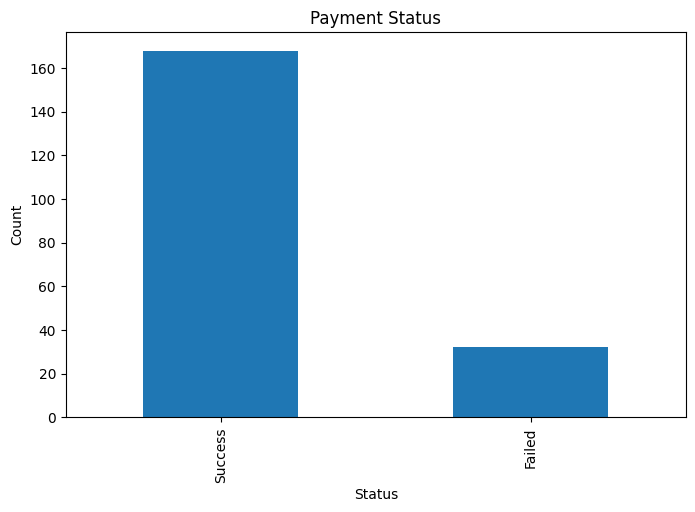

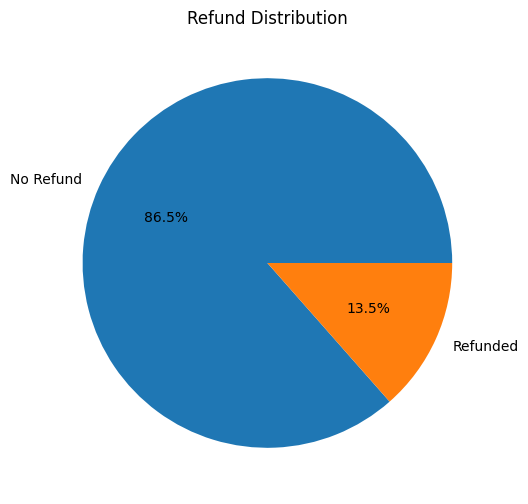

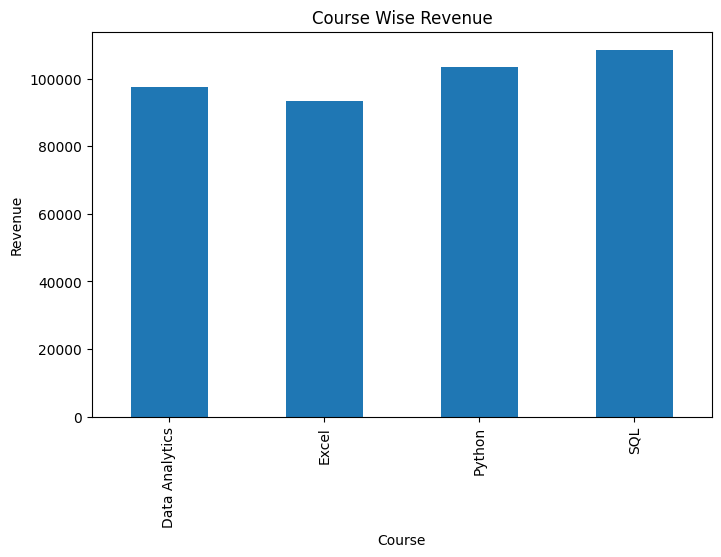

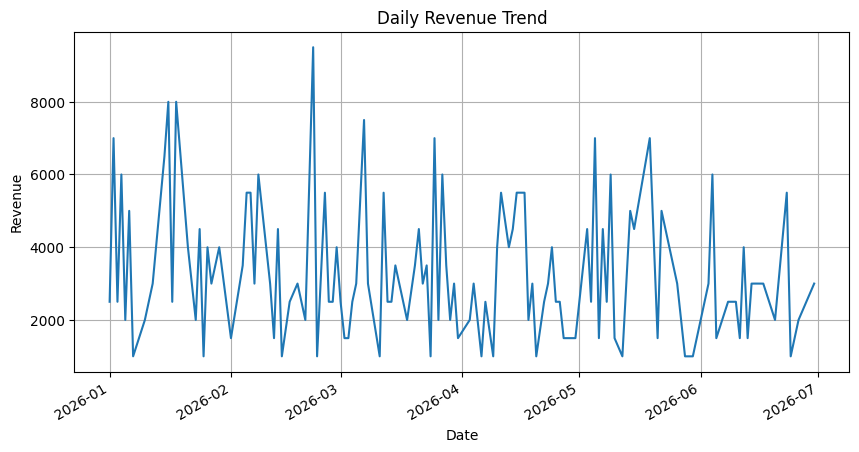

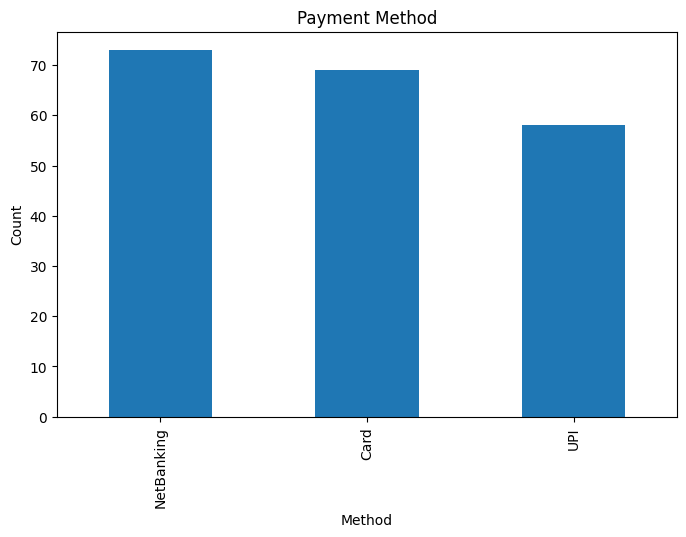

In [2]:
# ============================================
# CHARTS
# ============================================

plt.figure(figsize=(8,5))
df["Payment_Status"].value_counts().plot(kind="bar")
plt.title("Payment Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,6))
df["Refund_Status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Refund Distribution")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8,5))
df.groupby("Course")["Amount"].sum().plot(kind="bar")
plt.title("Course Wise Revenue")
plt.xlabel("Course")
plt.ylabel("Revenue")
plt.show()

plt.figure(figsize=(10,5))
df.groupby("Date")["Amount"].sum().plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
df["Payment_Method"].value_counts().plot(kind="bar")
plt.title("Payment Method")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()

In [3]:
# ============================================
# BUSINESS INSIGHTS
# ============================================

print("\n========== BUSINESS INSIGHTS ==========")

print("Highest Revenue Course :")
print(df.groupby("Course")["Amount"].sum().sort_values(ascending=False))

print("\nPayment Status")
print(df["Payment_Status"].value_counts())

print("\nRefund Status")
print(df["Refund_Status"].value_counts())

print("\nPayment Method")
print(df["Payment_Method"].value_counts())

# Save Clean Dataset
df.to_excel("Cleaned_Refund_Dataset.xlsx",index=False)

summary = pd.DataFrame({
    "Metric":[
        "Total Receipts",
        "Total Amount",
        "Successful Payments",
        "Failed Payments",
        "Refund Count",
        "Refund Amount"
    ],
    "Value":[
        total_receipts,
        total_amount,
        successful_payments,
        failed_payments,
        total_refunds,
        refund_amount
    ]
})

summary.to_excel("KPI_Report.xlsx",index=False)

print("\nFiles Saved Successfully!")
print("1. Cleaned_Refund_Dataset.xlsx")
print("2. KPI_Report.xlsx")


========== BUSINESS INSIGHTS ==========
Highest Revenue Course :
Course
SQL               108447
Python            103446
Data Analytics     97453
Excel              93454
Name: Amount, dtype: int64

Payment Status
Payment_Status
Success    168
Failed      32
Name: count, dtype: int64

Refund Status
Refund_Status
No Refund    173
Refunded      27
Name: count, dtype: int64

Payment Method
Payment_Method
NetBanking    73
Card          69
UPI           58
Name: count, dtype: int64

Files Saved Successfully!
1. Cleaned_Refund_Dataset.xlsx
2. KPI_Report.xlsx


In [4]:
# ============================================
# DASHBOARD DATA PREPARATION
# ============================================

import pandas as pd

# KPI
total_receipts = len(df)
total_amount = df["Amount"].sum()
successful = (df["Payment_Status"]=="Success").sum()
failed = (df["Payment_Status"]=="Failed").sum()
refunds = (df["Refund_Status"]=="Refunded").sum()
refund_amount = df["Refund_Amount"].sum()

success_rate = round(successful/total_receipts*100,2)
failure_rate = round(failed/total_receipts*100,2)
refund_rate = round(refunds/total_receipts*100,2)

print("="*50)
print("DASHBOARD KPI")
print("="*50)

print("Total Receipts :",total_receipts)
print("Total Revenue :",total_amount)
print("Successful Payments :",successful)
print("Failed Payments :",failed)
print("Refund Count :",refunds)
print("Refund Amount :",refund_amount)
print("Success Rate :",success_rate,"%")
print("Failure Rate :",failure_rate,"%")
print("Refund Rate :",refund_rate,"%")

DASHBOARD KPI
Total Receipts : 200
Total Revenue : 402800
Successful Payments : 168
Failed Payments : 32
Refund Count : 27
Refund Amount : 51473
Success Rate : 84.0 %
Failure Rate : 16.0 %
Refund Rate : 13.5 %


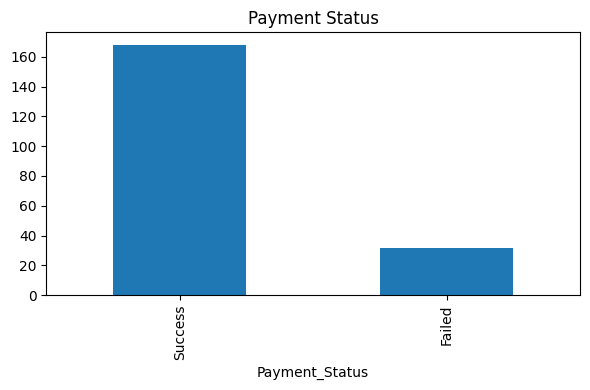

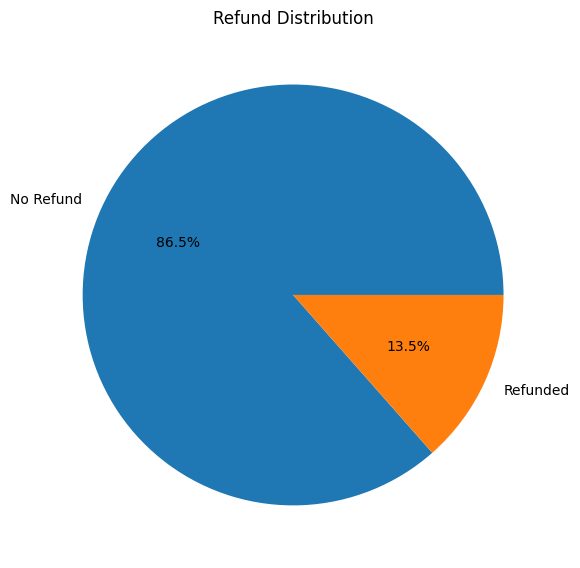

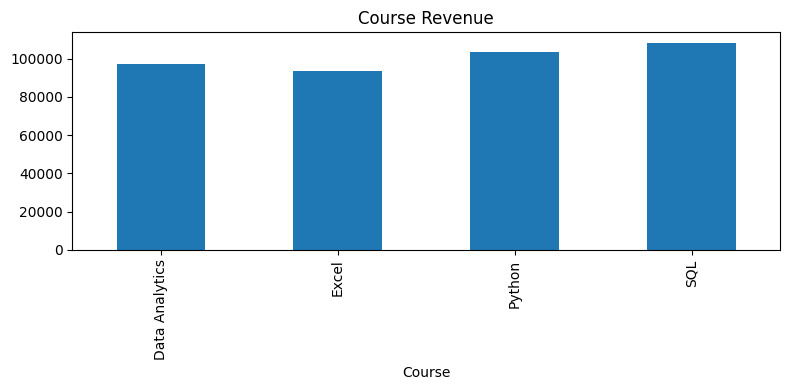

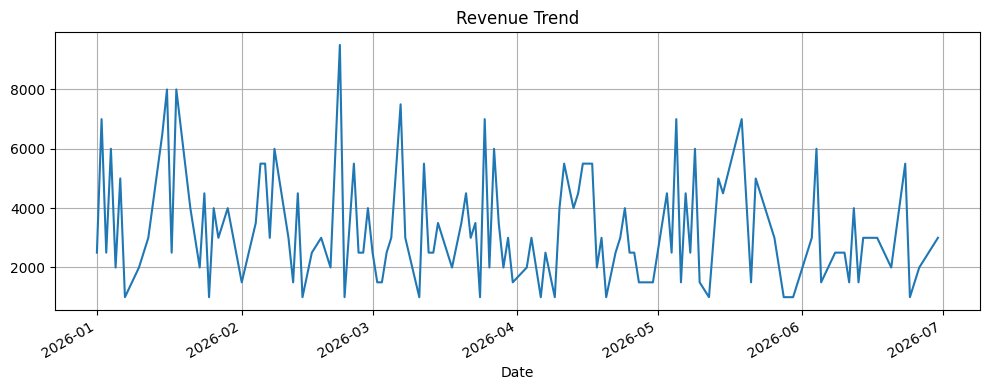

Charts Saved Successfully


In [5]:
# ============================================
# SAVE CHARTS
# ============================================

import matplotlib.pyplot as plt

# Chart 1
plt.figure(figsize=(6,4))
df["Payment_Status"].value_counts().plot(kind="bar")
plt.title("Payment Status")
plt.tight_layout()
plt.savefig("payment_status.png")
plt.show()

# Chart 2
plt.figure(figsize=(6,6))
df["Refund_Status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Refund Distribution")
plt.tight_layout()
plt.savefig("refund_distribution.png")
plt.show()

# Chart 3
plt.figure(figsize=(8,4))
df.groupby("Course")["Amount"].sum().plot(kind="bar")
plt.title("Course Revenue")
plt.tight_layout()
plt.savefig("course_revenue.png")
plt.show()

# Chart 4
plt.figure(figsize=(10,4))
df.groupby("Date")["Amount"].sum().plot()
plt.title("Revenue Trend")
plt.grid(True)
plt.tight_layout()
plt.savefig("revenue_trend.png")
plt.show()

print("Charts Saved Successfully")

In [6]:
# ============================================
# FINAL PROJECT SUMMARY
# ============================================

print("="*60)
print("REFUND & FAILURE ANALYTICS PROJECT")
print("="*60)

print("\nPROJECT COMPLETED SUCCESSFULLY\n")

print("Project Includes:")

print("✔️ Data Cleaning")
print("✔️ KPI Report")
print("✔️ Business Insights")
print("✔️ Revenue Analysis")
print("✔️ Refund Analysis")
print("✔️ Failure Analysis")
print("✔️ Payment Analysis")
print("✔️ Charts")
print("✔️ Excel Report")
print("✔️ Dashboard Ready")
print("✔️ GitHub Ready")

print("\nGenerated Files:")
print("1. Cleaned_Refund_Dataset.xlsx")
print("2. KPI_Report.xlsx")
print("3. payment_status.png")
print("4. refund_distribution.png")
print("5. course_revenue.png")
print("6. revenue_trend.png")

print("\nCongratulations!")
print("Project Phase 1 Completed.")

REFUND & FAILURE ANALYTICS PROJECT

PROJECT COMPLETED SUCCESSFULLY

Project Includes:
✔️ Data Cleaning
✔️ KPI Report
✔️ Business Insights
✔️ Revenue Analysis
✔️ Refund Analysis
✔️ Failure Analysis
✔️ Payment Analysis
✔️ Charts
✔️ Excel Report
✔️ Dashboard Ready
✔️ GitHub Ready

Generated Files:
1. Cleaned_Refund_Dataset.xlsx
2. KPI_Report.xlsx
3. payment_status.png
4. refund_distribution.png
5. course_revenue.png
6. revenue_trend.png

Congratulations!
Project Phase 1 Completed.


In [7]:
# ============================================
# CREATE GITHUB PROJECT FILES
# ============================================

# ---------- app.py ----------
app_code = '''
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Refund & Failure Analytics Dashboard", layout="wide")

st.title("Refund & Failure Analytics Dashboard")

df = pd.read_excel("Cleaned_Refund_Dataset.xlsx")

total_receipts = len(df)
total_amount = df["Amount"].sum()
successful = (df["Payment_Status"]=="Success").sum()
failed = (df["Payment_Status"]=="Failed").sum()
refunds = (df["Refund_Status"]=="Refunded").sum()
refund_amount = df["Refund_Amount"].sum()

col1,col2,col3 = st.columns(3)

col1.metric("Total Receipts", total_receipts)
col2.metric("Total Revenue", f"₹{total_amount}")
col3.metric("Successful Payments", successful)

col1,col2,col3 = st.columns(3)

col1.metric("Failed Payments", failed)
col2.metric("Refund Count", refunds)
col3.metric("Refund Amount", f"₹{refund_amount}")

st.subheader("Dataset Preview")
st.dataframe(df)
'''

with open("app.py","w",encoding="utf-8") as f:
    f.write(app_code)

# ---------- requirements.txt ----------
requirements = """streamlit
pandas
openpyxl
matplotlib
numpy
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

# ---------- README.md ----------
readme = """# Refund & Failure Analytics Dashboard

## Project Overview
This project analyzes payment receipts, payment failures and refunds using Python.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Streamlit
- Excel

## Features
- Data Cleaning
- KPI Report
- Refund Analytics
- Failure Analytics
- Revenue Analysis
- Dashboard

## Project Files
- app.py
- Cleaned_Refund_Dataset.xlsx
- KPI_Report.xlsx
- requirements.txt
- README.md
"""

with open("README.md","w",encoding="utf-8") as f:
    f.write(readme)

print("Files Created Successfully!")
print("app.py")
print("requirements.txt")
print("README.md")

Files Created Successfully!
app.py
requirements.txt
README.md
